# Gradient Descent Tutorial

## Introduction

Gradient Descent is an optimization algorithm used to minimize the cost function in machine learning models. It is particularly useful for linear regression and neural networks.

## Steps of Gradient Descent

**1. Initialize Parameters:** Start with random values for the model parameters.

**2. Compute the Cost Function:** Calculate the cost (or error) between the predicted values and the actual values.

**3. Compute the Gradient:** Determine the gradient of the cost function with respect to each parameter.

**4. Update Parameters:** Adjust the parameters by moving them in the direction opposite to the gradient.

**5. Repeat:** Iterate over the above steps until convergence (when the change in cost function is below a threshold).

## Code Implementation

### First, let's import the necessary libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Now, we'll generate sample data to work with

In [2]:
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

### Now we perform random initialization of parameters

In [3]:
theta = np.random.randn(2, 1)

### We add x0 = 1 to each instance to handle the bias term

In [4]:
X_b = np.c_[np.ones((100, 1)), X]  # add x0 = 1 to each instance

### Now, we define a function to compute the cost function

X is the Feature matrix. y contains the Target values. theta stores the Parameters (weights). This function returns the cost (mean squared error).

In [5]:
def compute_cost(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1/(2*m)) * np.sum(np.square(predictions - y))
    return cost

### Next, we define a function to compute the gradient

This function returns the gradients.


In [6]:
def compute_gradient(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    gradients = (1/m) * X.T.dot(predictions - y)
    return gradients

### Next, we define a function to update our parameters

This function is formed for optimizing parameters in linear regression. alpha is the learning rate. tol is the tolerance for stopping criteria. max_iterations indicates the maximum number of iterations. print_progress returns the frequency of printing progress.

In [7]:
def gradient_descent(X, y, theta, alpha=0.01, tol=1e-4, max_iterations=5000, print_progress=10):
    print(f"Iteration 0. theta = {theta.flatten()}.")
    iterations = 1            # Initialize iterations
    cost_history = [compute_cost(X, y, theta)]  # Initialize cost history
    change_in_cost = tol * 2  # Initialize change in cost

    while change_in_cost > tol and iterations <= max_iterations:
        gradients = compute_gradient(X, y, theta)  # Calculate current gradient
        theta -= alpha * gradients  # Update theta
        cost = compute_cost(X, y, theta)  # Calculate new cost
        change_in_cost = abs(cost_history[-1] - cost)  # Calculate change in cost
        cost_history.append(cost)  # Append new cost to history

        if iterations % print_progress == 0:
            print(f"Iteration {iterations}. theta = {theta.flatten()}. gradient = {gradients.flatten()}. cost = {cost:.5f}.")

        iterations += 1  # Increase iteration

    print("Terminated!")
    print(f"Iteration {iterations - 1}. theta = {theta.flatten()}. cost = {cost:.5f}.")
    return theta, cost_history

### Running gradient descent

In [8]:
initial_theta = np.random.randn(2, 1)
theta, cost_history = gradient_descent(X_b, y, initial_theta, alpha=0.01, print_progress=100)

Iteration 0. theta = [-0.26465683  2.72016917].
Iteration 100. theta = [1.86532807 4.34776034]. gradient = [-0.87755497 -0.27327478]. cost = 1.21459.
Iteration 200. theta = [2.40988383 4.30233005]. gradient = [-0.36621946  0.19327904]. cost = 0.88106.
Iteration 300. theta = [2.71390975 4.08792379]. gradient = [-0.26256566  0.21568884]. cost = 0.74191.
Iteration 400. theta = [2.95114933 3.88515966]. gradient = [-0.21578531  0.18852339]. cost = 0.64436.
Iteration 500. theta = [3.14893447 3.7113583 ]. gradient = [-0.18136135  0.1598836 ]. cost = 0.57493.
Iteration 600. theta = [3.3155257  3.56437057]. gradient = [-0.15294144  0.13500812]. cost = 0.52549.
Iteration 700. theta = [3.45605622 3.44030258]. gradient = [-0.12903886  0.11393047]. cost = 0.49029.
Iteration 800. theta = [3.57462935 3.33561054]. gradient = [-0.10887985  0.09613451]. cost = 0.46524.
Iteration 900. theta = [3.67467917 3.24727219]. gradient = [-0.09187115  0.08111717]. cost = 0.44739.
Iteration 1000. theta = [3.7590997

### Plotting the cost function

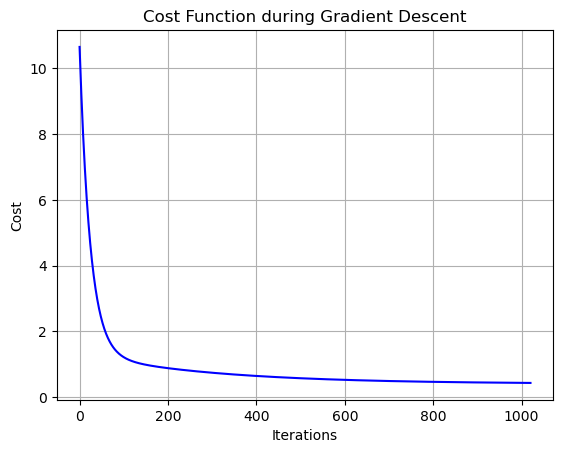

In [9]:
plt.plot(range(len(cost_history)), cost_history, 'b-')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost Function during Gradient Descent')
plt.grid(True)
plt.show()

### Result

In [10]:
print("Theta found by gradient descent:", theta)

Theta found by gradient descent: [[3.77433034]
 [3.15928564]]
